In [1]:
import pandas as pd

# Load the upLoaded dataset
file_path = "500_Person_Gender_Height_Weight_Index.csv"
df = pd.read_csv(file_path)

#Display the first few rows and general info
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [5]:
# Statistik deskriptif dasar untuk kolom numerik
desc_stats = df[['Height', 'Weight', 'Index']].describe().T

# Menambahkan median secara manual
desc_stats['median'] = df[['Height', 'Weight', 'Index']].median()

desc_stats

,count,mean,std,min,25%,50%,75%,max,median
Height,500.0,169.944,16.375261,140.0,156.0,170.5,184.0,199.0,170.5
Weight,500.0,106.000,32.382607,50.0,80.0,106.0,136.0,160.0,106.0
Index,500.0,3.748,1.355053,0.0,3.0,4.0,5.0,5.0,4.0


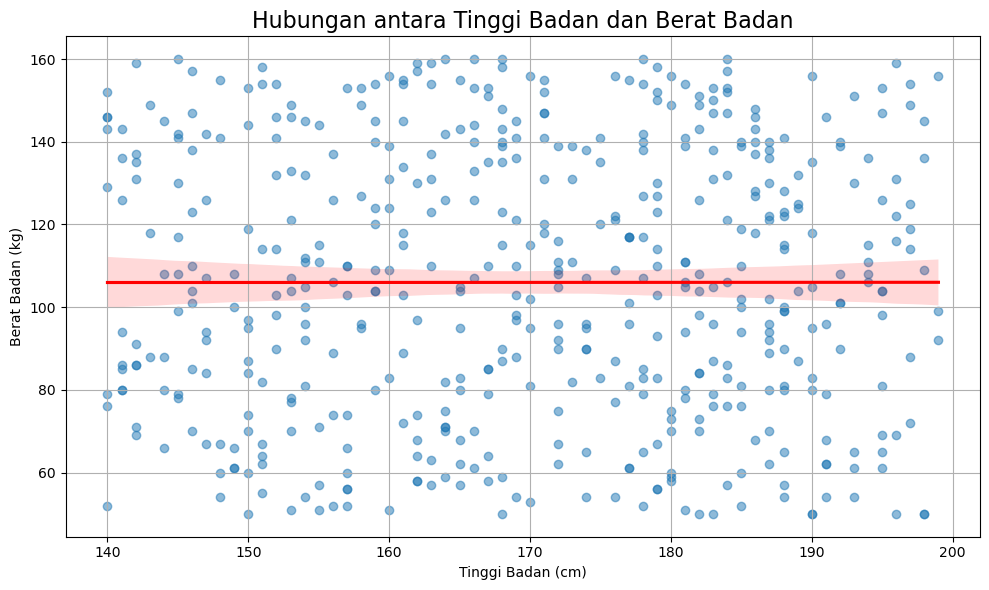

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Weight   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                 9.904e-05
Date:                Sat, 05 Jul 2025   Prob (F-statistic):              0.992
Time:                        18:37:46   Log-Likelihood:                -2447.8
No. Observations:                 500   AIC:                             4900.
Df Residuals:                     498   BIC:                             4908.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.8501     15.129      6.996      0.000      76.125     135.575
Height         0.0009      0.089      0.010      0.992      -0.173       0.175
==============================================================================
Omnibus:                      310.450   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.981
Skew:                          -0.038   Prob(JB):                     3.09e-07
Kurtosis:                       1.803   Cond. No.                     1.78e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.78e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

#Variabel independen dan dependen
X = df['Height']
y = df['Weight']

# Menambahkan konstanta untuk regresi linier
X_const = sm.add_constant(X)

# Model regresi linier
model = sm.OLS(y, X_const).fit()
regression_summary = model.summary()

# Visualisasi scatter plot + garis regresi
plt.figure(figsize=(10, 6))
sns.regplot(x='Height', y='Weight', data=df, line_kws={'color': 'red'},scatter_kws={'alpha':0.5})
plt.title('Hubungan antara Tinggi Badan dan Berat Badan', fontsize=16)
plt.xlabel('Tinggi Badan (cm)')
plt.ylabel('Berat Badan (kg)')
plt.grid(True)
plt.tight_layout()
plt.show()

regression_summary